### Online Retail – Customer Churn Detection

#### 1. Problem Definition
Customer churn refers to the phenomenon where customers stop purchasing from a business over a given period of time. In online retail, churn detection is especially challenging because there is no explicit cancellation event; instead, churn must be inferred from customer inactivity over time.

This project analyzes the UK Online Retail dataset to identify churned customers based on their historical transaction behavior. Churn is defined using an inactivity threshold, where customers who have not made a purchase within a specified time window are labeled as churned.

**Goal:** Predict customer churn using transactional behavior.

**Churn Definition:** A customer who has not made any purchase in the last 90 days is considered churned.

#### 2. Environment
    - Python 3.10 (Anaconda)
    - pandas, numpy, matplotlib, scikit-learn

#### 3. Data Loading
I load the raw transaction data to verify that it contains the essential fields (customer ID and dates) needed to build a behavioral churn definition for online retail.

In [1]:
import pandas as pd

df = pd.read_csv("online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### 4. Data Cleaning
The objective of this step is to make standardized and clean transaction data to enable precise measurement of customer behavior metrics (recency, frequency, and monetary value) used in churn analysis.

In [2]:
# Remove missing customers
df = df.dropna(subset=['CustomerID'])

# Remove invalid values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


By removing cancellations, invalid values, and anonymous customers, we ensure that churn signals reflect real purchasing behavior, not refunds, data errors, or one-off unidentified transactions.

#### 5. Exploratory Data Analysis (EDA)

**5.1. EDA(1)**

Identify the most active countries in the dataset to decide whether churn analysis should be focused on a single market (UK) or segmented by geography.

In [3]:
# Top countries by transactions
df['Country'].value_counts().head()

United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: Country, dtype: int64

**5.2. EDA(2)**

The dataset is heavily dominated by the UK, which justifies restricting churn modeling to UK customers to avoid bias from countries with sparse transaction data.

In [4]:
# Monthly sales trend
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Sales'].sum()
monthly_sales

InvoiceDate
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Sales, dtype: float64

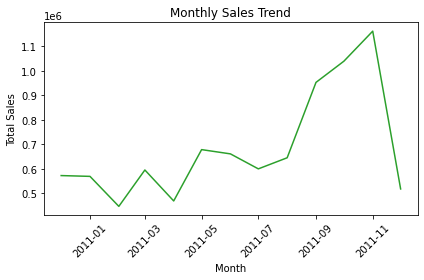

In [5]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values, color = 'tab:green')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- The monthly sales trend shows clear seasonality, with periods of high and low demand, indicating that short-term inactivity may be seasonal rather than true churn.
- Because sales fluctuate seasonally, churn should be defined using a sufficiently long inactivity window to avoid misclassifying seasonal customers as churned.

#### 6. Feature Engineering – RFM

RFM (Recency, Frequency, Monetary) is a widely used customer behavior framework in marketing analytics that summarizes purchasing patterns using three key dimensions: how recently a customer made a purchase, how often they purchase, and how much they spend. These features provide a compact and interpretable representation of customer value and engagement, and are commonly used for customer segmentation, churn analysis, and targeted marketing.

In [8]:
from datetime import timedelta

# Creating the snapshot date
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum' 
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In the code above, RFM features are constructed by aggregating transactional data at the customer level.

- A snapshot date is defined as one day after the last observed transaction in the dataset. This ensures that recency is calculated consistently for all customers and avoids zero-day recency values.

- Recency is computed as the number of days between the snapshot date and the customer’s most recent purchase, capturing how recently the customer has interacted with the business.

- Frequency is calculated as the number of unique invoices per customer, representing how often the customer makes purchases.

- Monetary value is obtained by summing total sales per customer, reflecting the customer’s overall spending.

The resulting RFM table provides a structured, customer-level feature set that can be directly used for churn labeling, exploratory analysis, or as input features for predictive models.

#### 7. Churn Labeling

In this step, a binary churn variable is created based on customer recency. Customers whose recency exceeds 90 days are classified as churned and assigned a value of 1, while customers who have made a purchase within the last 90 days are considered active and assigned a value of 0. The `value_counts()` function is used to examine the distribution of churned and non-churned customers in the dataset.

In [9]:
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)
rfm['Churn'].value_counts()

0    2889
1    1449
Name: Churn, dtype: int64

#### 8. Train-Test Split & Scaling

In this step, the dataset is prepared for predictive modeling. The RFM features (Recency, Frequency, and Monetary) are selected as input variables, while the churn indicator is used as the target variable. The data is split into training and test sets using an 80/20 ratio to allow for an unbiased evaluation of model performance. Stratified sampling is applied to preserve the original class distribution of churned and non-churned customers in both subsets.

Feature scaling is then performed using standardization, which transforms the features to have zero mean and unit variance. The scaler is fitted on the training data and subsequently applied to both the training and test sets. This approach prevents information leakage and ensures that all features contribute equally to the model training process.

- To avoid information leakage, all preprocessing steps such as scaling must be fitted only on the training data.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### 9. Modeling - Random Forest

In this step, a Random Forest classifier is used to train a churn prediction model. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve robustness and reduce overfitting.

The model is configured with 300 trees `n_estimators=300` to ensure stable and reliable predictions. The maximum depth of each tree is limited to 8 `max_depth=8` in order to control model complexity and prevent overfitting. Since churn datasets are typically imbalanced, the parameter `class_weight='balanced'` is applied so that the model assigns higher importance to the minority class (churned customers).

A fixed random seed `random_state=42` is used to ensure reproducibility of results. Finally, the model is trained using the scaled training features `X_train` and the corresponding churn labels `y_train`.

- Random Forest handles non-linear relationships well, is robust to noise, and performs effectively on tabular business data such as RFM features.

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
     n_estimators=300,
     max_depth=8,
     class_weight='balanced',
     random_state=42
)

model.fit(X_train, y_train)

# Check model parameters
#model.get_params()

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       random_state=42)

#### 10. Evaluation

The trained model is evaluated on the test dataset using several classification metrics. Predicted class labels and churn probabilities are generated to assess performance from different perspectives. The classification report summarizes precision, recall, and F1-score for each class, with particular emphasis on recall for churned customers, as identifying at-risk customers is critical in churn prediction.

The ROC-AUC score is used to measure the model’s overall ability to distinguish between churned and non-churned customers across different thresholds. Additionally, the confusion matrix provides a clear breakdown of correct and incorrect predictions, enabling analysis of model errors and their potential business impact.

In [15]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print('ROC-AUC:', roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       290

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868

ROC-AUC: 1.0
[[578   0]
 [  0 290]]


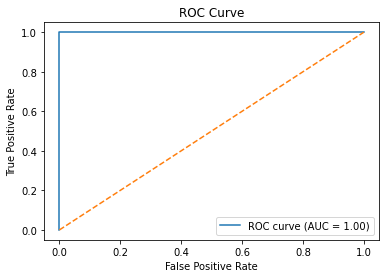

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across different classification thresholds. It visualizes the model’s ability to distinguish between churned and non-churned customers. The diagonal line represents a random classifier, while curves above this line indicate better-than-random performance. The area under the curve (AUC) summarizes this performance into a single value, where higher values indicate stronger discriminative ability.

- ROC-AUC evaluates the ranking quality of predictions and is robust to class imbalance, making it well suited for churn prediction problems

#### 11. Feature Importance

This step extracts feature importance scores from the trained Random Forest model. These scores indicate how much each feature contributes to the model’s predictions, based on how effectively the feature reduces impurity across all trees in the forest. The features are ranked in descending order to identify the most influential variables in predicting customer churn.

In [17]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Recency      0.862584
Frequency    0.072654
Monetary     0.064762
dtype: float64

The feature importance plot visualizes the relative contribution of each RFM feature to the Random Forest model. Features with higher importance values play a greater role in reducing impurity during tree splits, indicating stronger influence on churn predictions.

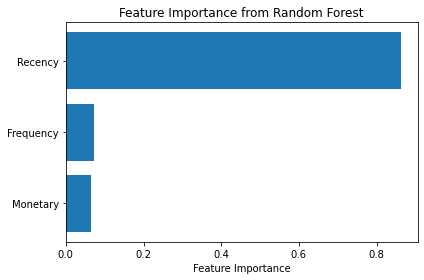

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Create importance Series
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

# Plot
plt.figure(figsize=(6, 4))
plt.barh(importance.index, importance.values)
plt.xlabel('Feature Importance')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

**For me:** I visualize feature importance using a horizontal bar chart, which clearly communicates the relative contribution of each feature and improves interpretability for non-technical stakeholder

#### 12. Conclusion

In this project, customer churn was analyzed using transactional online retail data by transforming purchase records into meaningful customer-level features through RFM analysis. A Random Forest classifier was trained to identify churned customers based on behavioral patterns, and its performance was evaluated using standard classification metrics and ROC-AUC.

The results demonstrate that recency, frequency, and monetary value provide informative signals for churn detection in a non-contractual retail setting. While the model shows promising predictive capability, the analysis also highlights the importance of careful feature engineering, proper evaluation, and awareness of class imbalance. This work provides a solid foundation for further improvements, such as threshold optimization, alternative models, or more advanced interpretability techniques.

#### 13. Future Work
The analysis could be further improved by enriching the feature set with additional customer behavior metrics and by testing alternative modeling approaches to identify the best balance between model transparency and predictive performance.